In [36]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    LSTM,
    TimeDistributed
)
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [38]:
print("Greetings:")
print(os.listdir("Greetings"))

print("\nGreetings2:")
print(os.listdir("Greetings2"))

Greetings:
['.ipynb_checkpoints', '48. Hello', '49. How are you', '50. Alright', '51. Good Morning', '52. Good afternoon']

Greetings2:
['.ipynb_checkpoints', '53. Good evening', '54. Good night', '55. Thank you']


In [39]:
video_extensions = (".mp4", ".avi", ".mov", ".mkv", ".webm")

video_files = []

for folder in ["Greetings", "Greetings2", "Training", "Validation", "Testing"]:
    if os.path.exists(folder):
        for root, dirs, files in os.walk(folder):
            for file in files:
                if file.lower().endswith(video_extensions):
                    video_files.append(os.path.join(root, file))

print("Total videos found:", len(video_files))

for video in video_files[:30]:
    print(video)

Total videos found: 146
Greetings\48. Hello\MVI_0029.MOV
Greetings\48. Hello\MVI_0030.MOV
Greetings\48. Hello\MVI_0031.MOV
Greetings\48. Hello\MVI_0032.MOV
Greetings\48. Hello\MVI_0037.MOV
Greetings\48. Hello\MVI_0038.MOV
Greetings\48. Hello\MVI_0039.MOV
Greetings\48. Hello\MVI_0089.MOV
Greetings\48. Hello\MVI_0090.MOV
Greetings\48. Hello\MVI_0091.MOV
Greetings\48. Hello\MVI_9914.MOV
Greetings\48. Hello\MVI_9915.MOV
Greetings\48. Hello\MVI_9916.MOV
Greetings\48. Hello\MVI_9917.MOV
Greetings\48. Hello\MVI_9954.MOV
Greetings\48. Hello\MVI_9955.MOV
Greetings\48. Hello\MVI_9956.MOV
Greetings\48. Hello\MVI_9957.MOV
Greetings\48. Hello\MVI_9982.MOV
Greetings\48. Hello\MVI_9983.MOV
Greetings\48. Hello\MVI_9984.MOV
Greetings\49. How are you\MVI_0033.MOV
Greetings\49. How are you\MVI_0034.MOV
Greetings\49. How are you\MVI_0035.MOV
Greetings\49. How are you\MVI_0036.MOV
Greetings\49. How are you\MVI_0040.MOV
Greetings\49. How are you\MVI_0041.MOV
Greetings\49. How are you\MVI_0042.MOV
Greetings\

In [40]:
from collections import Counter
# Label for videos
video_labels = []

for video in video_files:

    class_name = os.path.basename(os.path.dirname(video))
    video_labels.append(class_name)

label_counts = Counter(video_labels)

print("Number of classes:", len(label_counts))
print("\nVideos per class:")

for label, count in sorted(label_counts.items()):
    print(label, "->", count)

Number of classes: 8

Videos per class:
48. Hello -> 21
49. How are you -> 21
50. Alright -> 21
51. Good Morning -> 1
52. Good afternoon -> 22
53. Good evening -> 18
54. Good night -> 21
55. Thank you -> 21


In [41]:
IMG_SIZE = 128
NUM_FRAMES = 20

print("Image size:", IMG_SIZE)
print("Frames per video:", NUM_FRAMES)

Image size: 128
Frames per video: 20


In [42]:
def extract_frames(video_path, num_frames=NUM_FRAMES, img_size=IMG_SIZE):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    frame_indices = np.linspace(
        0, total_frames - 1, num_frames
    ).astype(int)

    frames = []

    for index in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, index)

        success, frame = cap.read()

        if success:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frame = frame.astype("float32") / 255.0
            frames.append(frame)

    cap.release()

    # Make sure every video has exactly NUM_FRAMES
    if len(frames) != num_frames:
        return None

    return np.array(frames)

In [43]:
test_video = video_files[0]

frames = extract_frames(test_video)

print("Video:", test_video)

if frames is not None:
    print("Frames shape:", frames.shape)
else:
    print("Could not read video")

Video: Greetings\48. Hello\MVI_0029.MOV
Frames shape: (20, 128, 128, 3)


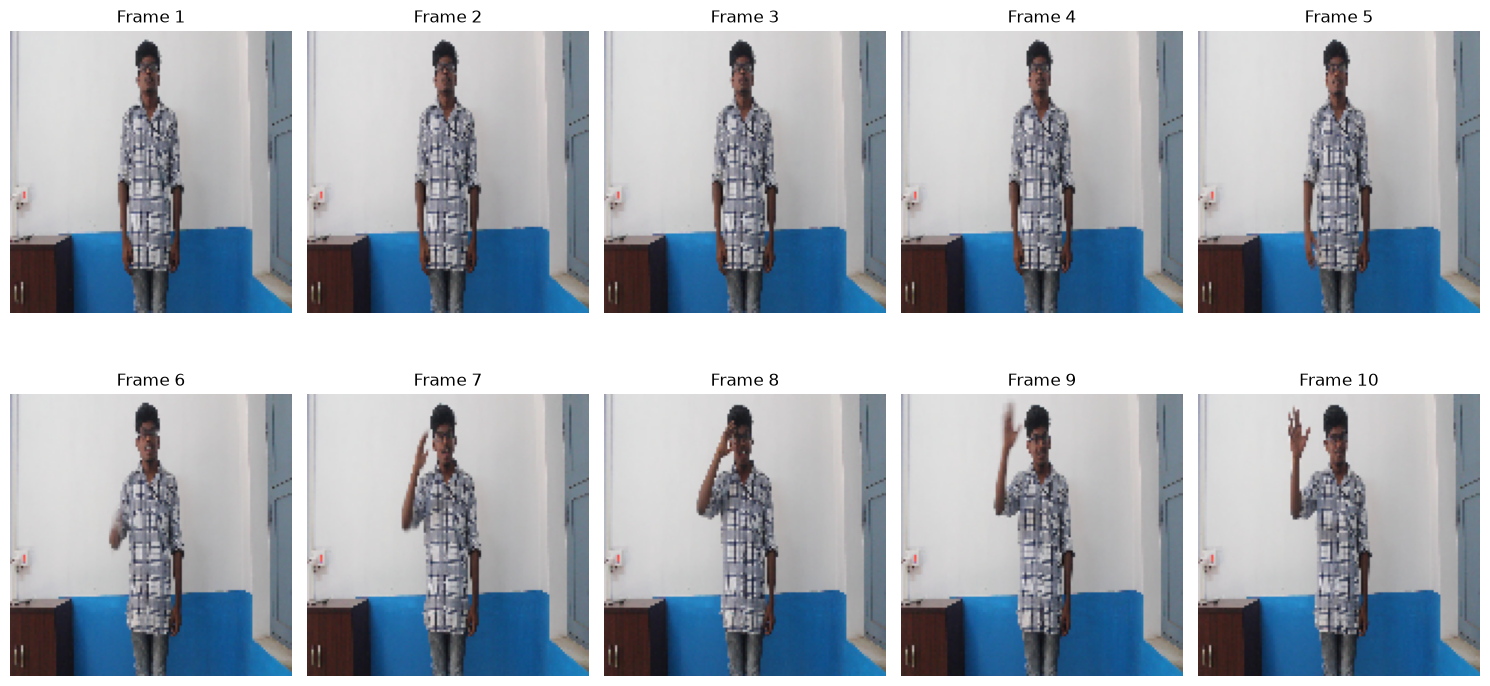

In [44]:
plt.figure(figsize=(15, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(frames[i])
    plt.title(f"Frame {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [52]:
# Remove Good Morning because it has only 1 video

valid_videos = []
valid_labels = []

for video, label in zip(video_files, video_labels):
    if label != "51. Good Morning":
        valid_videos.append(video)
        valid_labels.append(label)

video_files = valid_videos
video_labels = valid_labels

print("Total videos:", len(video_files))
print("Classes:", sorted(set(video_labels)))

Total videos: 145
Classes: ['48. Hello', '49. How are you', '50. Alright', '52. Good afternoon', '53. Good evening', '54. Good night', '55. Thank you']


In [53]:
for i, video_path in enumerate(video_files):

    # Get class name from folder
    class_name = os.path.basename(os.path.dirname(video_path))

    # Extract frames
    frames = extract_frames(video_path)

    if frames is not None:
        X.append(frames)
        y.append(label_to_index[class_name])

    print(
        f"Processed {i + 1}/{len(video_files)}: "
        f"{class_name}"
    )

Processed 1/145: 48. Hello
Processed 2/145: 48. Hello
Processed 3/145: 48. Hello
Processed 4/145: 48. Hello
Processed 5/145: 48. Hello
Processed 6/145: 48. Hello
Processed 7/145: 48. Hello
Processed 8/145: 48. Hello
Processed 9/145: 48. Hello
Processed 10/145: 48. Hello
Processed 11/145: 48. Hello
Processed 12/145: 48. Hello
Processed 13/145: 48. Hello
Processed 14/145: 48. Hello
Processed 15/145: 48. Hello
Processed 16/145: 48. Hello
Processed 17/145: 48. Hello
Processed 18/145: 48. Hello
Processed 19/145: 48. Hello
Processed 20/145: 48. Hello
Processed 21/145: 48. Hello
Processed 22/145: 49. How are you
Processed 23/145: 49. How are you
Processed 24/145: 49. How are you
Processed 25/145: 49. How are you
Processed 26/145: 49. How are you
Processed 27/145: 49. How are you
Processed 28/145: 49. How are you
Processed 29/145: 49. How are you
Processed 30/145: 49. How are you
Processed 31/145: 49. How are you
Processed 32/145: 49. How are you
Processed 33/145: 49. How are you
Processed 34/

In [60]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (145, 20, 128, 128, 3)
y shape: (145,)


In [61]:
unique, counts = np.unique(y, return_counts=True)

for class_index, count in zip(unique, counts):
    print(
        label_names[class_index],
        "->",
        count,
        "videos"
    )

48. Hello -> 21 videos
49. How are you -> 21 videos
50. Alright -> 21 videos
52. Good afternoon -> 22 videos
53. Good evening -> 18 videos
54. Good night -> 21 videos
55. Thank you -> 21 videos


In [67]:
train_videos, test_videos, train_labels, test_labels = train_test_split(
    video_files,
    video_labels,
    test_size=0.2,
    random_state=42,
    stratify=video_labels
)

print("Training videos:", len(train_videos))
print("Testing videos:", len(test_videos))

Training videos: 116
Testing videos: 29


In [68]:
print("Training distribution:")

train_counts = Counter(train_labels)

for label, count in sorted(train_counts.items()):
    print(label, "->", count)

print("\nTesting distribution:")

test_counts = Counter(test_labels)

for label, count in sorted(test_counts.items()):
    print(label, "->", count)

Training distribution:
48. Hello -> 17
49. How are you -> 17
50. Alright -> 17
52. Good afternoon -> 17
53. Good evening -> 14
54. Good night -> 17
55. Thank you -> 17

Testing distribution:
48. Hello -> 4
49. How are you -> 4
50. Alright -> 4
52. Good afternoon -> 5
53. Good evening -> 4
54. Good night -> 4
55. Thank you -> 4


In [69]:
from collections import Counter

print("Training distribution:")

train_counts = Counter(train_labels)

for label, count in sorted(train_counts.items()):
    print(label, "->", count)

print("\nTesting distribution:")

test_counts = Counter(test_labels)

for label, count in sorted(test_counts.items()):
    print(label, "->", count)

Training distribution:
48. Hello -> 17
49. How are you -> 17
50. Alright -> 17
52. Good afternoon -> 17
53. Good evening -> 14
54. Good night -> 17
55. Thank you -> 17

Testing distribution:
48. Hello -> 4
49. How are you -> 4
50. Alright -> 4
52. Good afternoon -> 5
53. Good evening -> 4
54. Good night -> 4
55. Thank you -> 4


In [70]:
IMG_SIZE = 128
NUM_FRAMES = 20

def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        NUM_FRAMES
    ).astype(int)

    frames = []

    for index in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, index)

        success, frame = cap.read()

        if success:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))

            # Normalize pixel values
            frame = frame.astype("float32") / 255.0

            frames.append(frame)

    cap.release()

    if len(frames) != NUM_FRAMES:
        return None

    return np.array(frames)

In [71]:
sample_video = train_videos[0]

sample_frames = extract_frames(sample_video)

print("Video:", sample_video)

if sample_frames is not None:
    print("Frames shape:", sample_frames.shape)
else:
    print("Could not read video")

Video: Greetings\52. Good afternoon\MVI_9938.MOV
Frames shape: (20, 128, 128, 3)


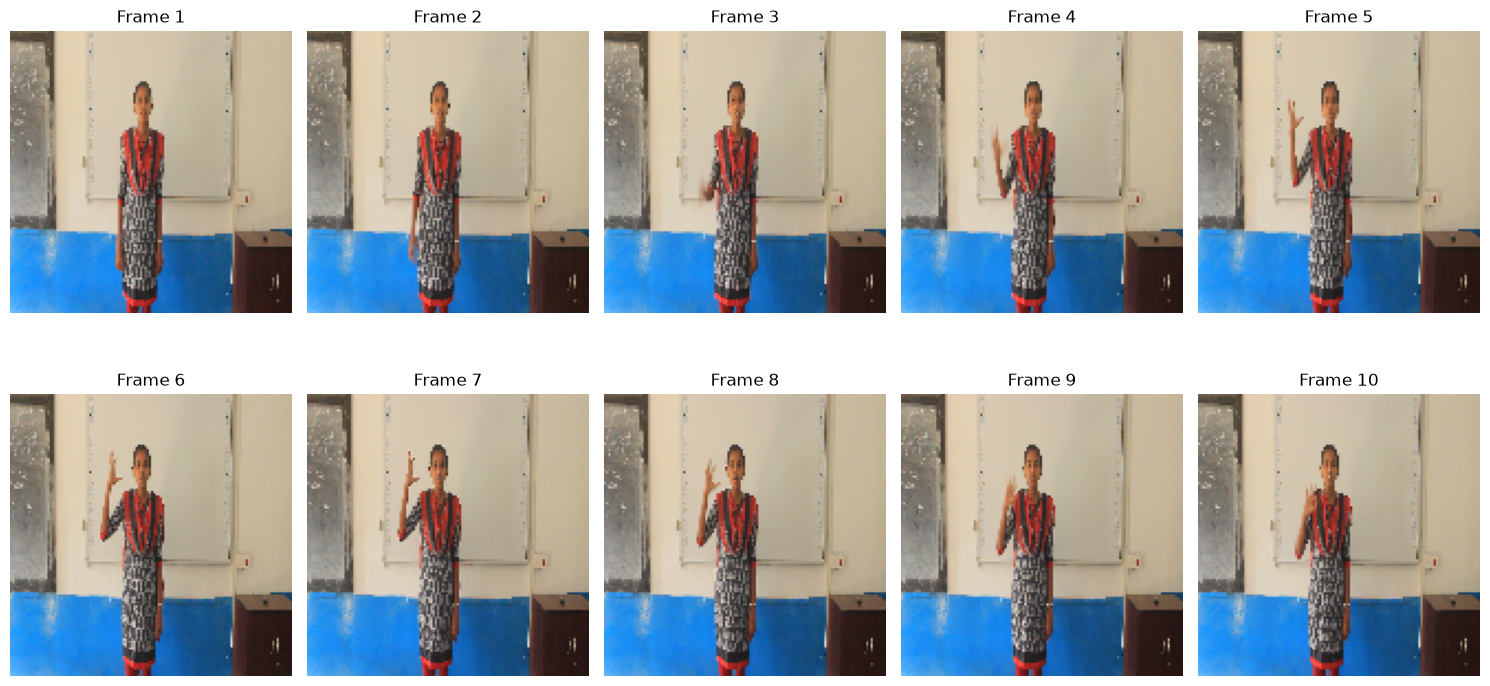

In [72]:
plt.figure(figsize=(15, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_frames[i])
    plt.title(f"Frame {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [73]:
X_train_frames = []
y_train_frames = []

for i, (video_path, label) in enumerate(zip(train_videos, train_labels)):

    frames = extract_frames(video_path)

    if frames is not None:
        # Add every frame separately
        for frame in frames:
            X_train_frames.append(frame)
            y_train_frames.append(label)

    print(f"Processed {i + 1}/{len(train_videos)}")

Processed 1/116
Processed 2/116
Processed 3/116
Processed 4/116
Processed 5/116
Processed 6/116
Processed 7/116
Processed 8/116
Processed 9/116
Processed 10/116
Processed 11/116
Processed 12/116
Processed 13/116
Processed 14/116
Processed 15/116
Processed 16/116
Processed 17/116
Processed 18/116
Processed 19/116
Processed 20/116
Processed 21/116
Processed 22/116
Processed 23/116
Processed 24/116
Processed 25/116
Processed 26/116
Processed 27/116
Processed 28/116
Processed 29/116
Processed 30/116
Processed 31/116
Processed 32/116
Processed 33/116
Processed 34/116
Processed 35/116
Processed 36/116
Processed 37/116
Processed 38/116
Processed 39/116
Processed 40/116
Processed 41/116
Processed 42/116
Processed 43/116
Processed 44/116
Processed 45/116
Processed 46/116
Processed 47/116
Processed 48/116
Processed 49/116
Processed 50/116
Processed 51/116
Processed 52/116
Processed 53/116
Processed 54/116
Processed 55/116
Processed 56/116
Processed 57/116
Processed 58/116
Processed 59/116
Proces

In [74]:
X_test_frames = []
y_test_frames = []

for i, (video_path, label) in enumerate(zip(test_videos, test_labels)):

    frames = extract_frames(video_path)

    if frames is not None:
        for frame in frames:
            X_test_frames.append(frame)
            y_test_frames.append(label)

    print(f"Processed {i + 1}/{len(test_videos)}")

Processed 1/29
Processed 2/29
Processed 3/29
Processed 4/29
Processed 5/29
Processed 6/29
Processed 7/29
Processed 8/29
Processed 9/29
Processed 10/29
Processed 11/29
Processed 12/29
Processed 13/29
Processed 14/29
Processed 15/29
Processed 16/29
Processed 17/29
Processed 18/29
Processed 19/29
Processed 20/29
Processed 21/29
Processed 22/29
Processed 23/29
Processed 24/29
Processed 25/29
Processed 26/29
Processed 27/29
Processed 28/29
Processed 29/29


In [75]:
X_train_frames = np.array(X_train_frames)
X_test_frames = np.array(X_test_frames)

y_train_frames = np.array(y_train_frames)
y_test_frames = np.array(y_test_frames)

print("Training data:", X_train_frames.shape)
print("Training labels:", y_train_frames.shape)

print("Testing data:", X_test_frames.shape)
print("Testing labels:", y_test_frames.shape)

Training data: (2320, 128, 128, 3)
Training labels: (2320,)
Testing data: (580, 128, 128, 3)
Testing labels: (580,)


In [76]:
# Get the 7 classes in a fixed order
classes = sorted(set(train_labels))

print("Classes:")
for i, class_name in enumerate(classes):
    print(i, "->", class_name)

Classes:
0 -> 48. Hello
1 -> 49. How are you
2 -> 50. Alright
3 -> 52. Good afternoon
4 -> 53. Good evening
5 -> 54. Good night
6 -> 55. Thank you


In [77]:
label_to_index = {
    label: i for i, label in enumerate(classes)
}

y_train_encoded = np.array([
    label_to_index[label] for label in y_train_frames
])

y_test_encoded = np.array([
    label_to_index[label] for label in y_test_frames
])

print("Training labels:", y_train_encoded[:20])
print("Testing labels:", y_test_encoded[:20])

Training labels: [3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
Testing labels: [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]


In [78]:
num_classes = len(classes)

y_train_categorical = to_categorical(
    y_train_encoded,
    num_classes=num_classes
)

y_test_categorical = to_categorical(
    y_test_encoded,
    num_classes=num_classes
)

print("Number of classes:", num_classes)
print("Training label shape:", y_train_categorical.shape)
print("Testing label shape:", y_test_categorical.shape)

Number of classes: 7
Training label shape: (2320, 7)
Testing label shape: (580, 7)


In [79]:
model = Sequential([
    
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

model.summary()

C:\Users\Razik Rahman\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [81]:
history = model.fit(
    X_train_frames,
    y_train_categorical,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.1676 - loss: 1.9564 - val_accuracy: 0.0259 - val_loss: 1.9605
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.3351 - loss: 1.6744 - val_accuracy: 0.1961 - val_loss: 1.6785
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.5819 - loss: 1.0947 - val_accuracy: 0.4698 - val_loss: 1.3522
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.6773 - loss: 0.8271 - val_accuracy: 0.4483 - val_loss: 1.3479
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.7355 - loss: 0.6525 - val_accuracy: 0.5366 - val_loss: 1.4858
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.7829 - loss: 0.5604 - val_accuracy: 0.5884 - val_loss: 1.2590
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.8125 - loss: 0.4814 - val_accuracy: 0.5991 - val_loss: 1.2466
Epoch 8/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.8394 - loss: 0.3966 - val_accuracy: 0.5927 - v

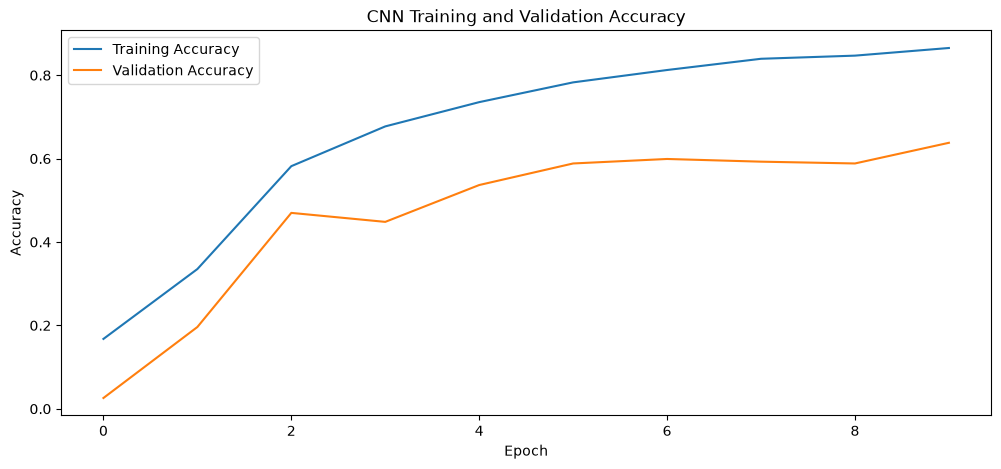

In [82]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.show()

In [83]:
test_loss, test_accuracy = model.evaluate(
    X_test_frames,
    y_test_categorical,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6672 - loss: 1.2198
Test Loss: 1.2198494672775269
Test Accuracy: 0.6672413945198059


In [84]:
y_pred_prob = model.predict(X_test_frames)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions:", y_pred[:20])
print("Actual:", y_test_encoded[:20])

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Predictions: [6 6 6 6 6 5 5 5 6 5 6 5 5 5 5 5 6 6 6 6]
Actual: [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]


In [85]:
print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=classes
    )
)

                    precision    recall  f1-score   support

         48. Hello       0.62      0.85      0.72        80
   49. How are you       0.78      0.49      0.60        80
       50. Alright       0.69      0.75      0.72        80
52. Good afternoon       0.78      0.60      0.68       100
  53. Good evening       0.54      0.89      0.67        80
    54. Good night       0.78      0.36      0.50        80
     55. Thank you       0.69      0.75      0.72        80

          accuracy                           0.67       580
         macro avg       0.70      0.67      0.66       580
      weighted avg       0.70      0.67      0.66       580



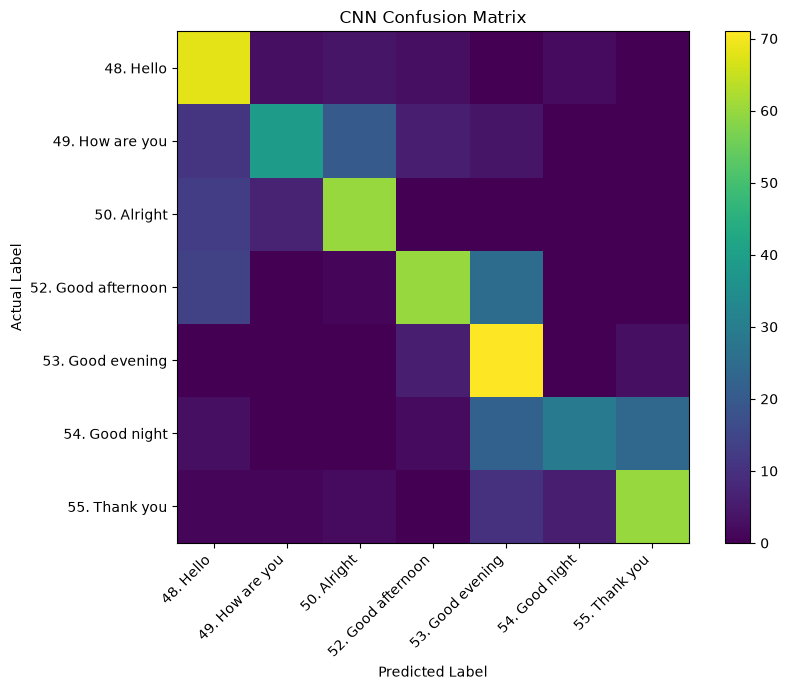

In [86]:
cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    range(len(classes)),
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.colorbar()
plt.tight_layout()
plt.show()

In [88]:
def predict_video(video_path):

    frames = extract_frames(video_path)

    if frames is None:
        print("Could not read video.")
        return None

    predictions = model.predict(frames, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    counts = np.bincount(
        predicted_classes,
        minlength=num_classes
    )

    final_class_index = np.argmax(counts)

    final_label = classes[final_class_index]

    confidence = counts[final_class_index] / len(predicted_classes)

    return final_label, confidence

In [89]:
test_video = test_videos[0]

print("Actual:", test_labels[0])
print("Video:", test_video)

result = predict_video(test_video)

if result is not None:
    predicted_label, confidence = result

    print("\nPredicted:", predicted_label)
    print("Confidence:", f"{confidence * 100:.2f}%")

Actual: 54. Good night
Video: Greetings2\54. Good night\MVI_005_6.MOV

Predicted: 55. Thank you
Confidence: 55.00%


In [90]:
correct = 0
total = len(test_videos)

for video_path, actual_label in zip(test_videos, test_labels):

    result = predict_video(video_path)

    if result is not None:
        predicted_label, confidence = result

        if predicted_label == actual_label:
            correct += 1

        print(
            f"Actual: {actual_label} | "
            f"Predicted: {predicted_label} | "
            f"Confidence: {confidence * 100:.1f}%"
        )

print("\nVideo-level accuracy:",
      f"{(correct / total) * 100:.2f}%")

Actual: 54. Good night | Predicted: 55. Thank you | Confidence: 55.0%
Actual: 54. Good night | Predicted: 55. Thank you | Confidence: 65.0%
Actual: 52. Good afternoon | Predicted: 53. Good evening | Confidence: 75.0%
Actual: 53. Good evening | Predicted: 53. Good evening | Confidence: 85.0%
Actual: 49. How are you | Predicted: 49. How are you | Confidence: 85.0%
Actual: 53. Good evening | Predicted: 53. Good evening | Confidence: 80.0%
Actual: 49. How are you | Predicted: 49. How are you | Confidence: 100.0%
Actual: 48. Hello | Predicted: 48. Hello | Confidence: 100.0%
Actual: 55. Thank you | Predicted: 55. Thank you | Confidence: 85.0%
Actual: 52. Good afternoon | Predicted: 52. Good afternoon | Confidence: 85.0%
Actual: 55. Thank you | Predicted: 55. Thank you | Confidence: 75.0%
Actual: 52. Good afternoon | Predicted: 52. Good afternoon | Confidence: 65.0%
Actual: 50. Alright | Predicted: 48. Hello | Confidence: 65.0%
Actual: 55. Thank you | Predicted: 55. Thank you | Confidence: 75

In [91]:
model.save("greeting_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [92]:
import json

with open("greeting_classes.json", "w") as file:
    json.dump(classes, file)

print("Classes saved:")
print(classes)

Classes saved:
['48. Hello', '49. How are you', '50. Alright', '52. Good afternoon', '53. Good evening', '54. Good night', '55. Thank you']


In [93]:
loaded_model = tf.keras.models.load_model(
    "greeting_cnn.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


In [94]:
test_video = test_videos[0]

frames = extract_frames(test_video)

predictions = loaded_model.predict(
    frames,
    verbose=0
)

predicted_classes = np.argmax(predictions, axis=1)

counts = np.bincount(
    predicted_classes,
    minlength=len(classes)
)

final_index = np.argmax(counts)

print("Actual:", test_labels[0])
print("Predicted:", classes[final_index])

Actual: 54. Good night
Predicted: 55. Thank you


In [96]:
def predict_greeting(video_path, model, classes):
    
    frames = extract_frames(video_path)

    if frames is None:
        return None, 0.0

    predictions = model.predict(frames, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    counts = np.bincount(
        predicted_classes,
        minlength=len(classes)
    )

    final_index = np.argmax(counts)

    final_label = classes[final_index]

    confidence = counts[final_index] / len(predicted_classes)

    return final_label, confidence

In [97]:
test_video = test_videos[0]

prediction, confidence = predict_greeting(
    test_video,
    loaded_model,
    classes
)

print("Video:", test_video)
print("Predicted Greeting:", prediction)
print("Confidence:", f"{confidence * 100:.2f}%")

Video: Greetings2\54. Good night\MVI_005_6.MOV
Predicted Greeting: 55. Thank you
Confidence: 55.00%


In [99]:
video_path = input("Enter video path: ")

prediction, confidence = predict_greeting(
    video_path,
    loaded_model,
    classes
)

if prediction is not None:
    print("\nPredicted Greeting:", prediction)
    print("Confidence:", f"{confidence * 100:.2f}%")
else:
    print("Could not process the video.")

Enter video path:  Greetings\48. Hello\MVI_0029.MOV



Predicted Greeting: 48. Hello
Confidence: 100.00%
